# CPER Soil-Moisture — Run Locally

Real-time soil-moisture mapping for the USDA-ARS **Central Plains Experimental
Range** — ~15,000 acres of shortgrass steppe in Weld County, CO
(NEON site `CPER`, 40.8155 / −104.7456).

**This notebook runs the entire pipeline on your laptop. No Pegasus, no
HTCondor, no cluster.** Every cell calls the same script Pegasus executes on a
pool, as a subprocess — so what you see here is exactly what runs there, and
the two cannot drift apart.

To run the same workflow as a DAG on a pool, see
**`Access-CPER-SoilMoisture-Workflow.ipynb`**.

### What the workflow answers

The CPER researcher asked for three things, in order:

| # | Ask | Stage | Status |
|---|-----|-------|--------|
| 1 | Characterize each station's historical soil-moisture response, relate it to soil/topography/climate, and visualize it | `station_response` → `station_similarity` → `visualize_response` | **M3, built** |
| 2 | Delineate areas expected to behave similarly | `delineate_zones` | **M3, built** |
| 3 | Estimate current soil moisture site-wide, updating as new data arrive | `soil_moisture_map` (point scale) → `estimate_soil_moisture` → `visualize_soil_moisture` | **M4, built** |

`SPEC.md` is the single design document; `README.md` has the command-line
equivalent of everything here.

## 0. Setup

Dependencies match the workflow container (`kthare10/cper-soilmoisture:m3`):
pandas, numpy, requests, rasterio, scikit-learn, matplotlib. In the project
`.venv` they are already installed; otherwise `pip install -r requirements.txt`.

In [1]:
import json
import os
import subprocess
import sys
from datetime import date
from pathlib import Path

import pandas as pd

# Submit hosts are often older than a laptop: ACCESS Pegasus ships Python 3.6,
# where subprocess.run has neither capture_output nor text (both 3.7+). Use the
# portable spelling so these notebooks run there unchanged.
def sh(cmd):
    # Returns (returncode, combined stdout+stderr).
    p = subprocess.run([str(c) for c in cmd], stdout=subprocess.PIPE,
                       stderr=subprocess.STDOUT, universal_newlines=True)
    return p.returncode, p.stdout or ""


WF = Path.cwd()                      # notebook lives in the workflow root
BIN = WF / "bin"
CONFIG = WF / "site_config.json"

assert BIN.exists(), f"run this notebook from the workflow root; got {WF}"
print("python :", sys.version.split()[0])
print("workflow root:", WF)

OUT = WF / "output" / "local"        # keep notebook artifacts separate
OUT.mkdir(parents=True, exist_ok=True)


def run_stage(script, *args, must_succeed=False):
    # Run one workflow stage exactly as Pegasus would, showing its log.
    # sys.executable keeps the stage in this kernel's interpreter, and the
    # output is the same text you would read in a Pegasus job's .out file.
    cmd = [sys.executable, str(BIN / script)] + [str(a) for a in args]
    print("$ %s %s\n" % (script, " ".join(str(a) for a in args)))
    rc, log = sh(cmd)
    for line in log.strip().splitlines()[-12:]:
        print("   ", line)
    print("\n   -> exit %d" % rc)
    if rc != 0 and must_succeed:
        raise RuntimeError("%s exited %d" % (script, rc))
    return rc


print("outputs ->", OUT)

python : 3.11.9
workflow root: /home/user/cper-soilmoisture-workflow
outputs -> /home/user/cper-soilmoisture-workflow/output/local


### Run configuration

Fingerprinting needs a long record, so the default window is multi-year. SCAN
and USCRN are anonymous; **NEON needs a free token**
(data.neonscience.org → My Account → API Tokens). Without it the NEON source
is skipped and the run continues on SCAN — the same graceful degradation the
workflow uses on a pool.

USCRN is off by default: `www.ncei.noaa.gov` has been unreachable from several
networks, and the on-site Nunn station stopped publishing on 2026-05-28, so
enabling it mostly buys ~35 minutes of retries.

In [2]:
START = "2014-01-01"                 # long enough for real fingerprints
END   = str(date.today())

# Optional: paste a NEON token here, or export NEON_TOKEN before launching.
NEON_TOKEN = os.environ.get("NEON_TOKEN", "")

SOURCES = ["awdb"]                   # SCAN: anonymous, 5 depths, back to 1997
if NEON_TOKEN:
    SOURCES.append("neon")           # 5 soil plots, ~38 depth-nodes
    os.environ["NEON_TOKEN"] = NEON_TOKEN

INCLUDE_USCRN = False
if INCLUDE_USCRN:
    SOURCES.insert(0, "uscrn")

print("window :", START, "->", END)
print("sources:", ", ".join(SOURCES))
print("NEON   :", "token present" if NEON_TOKEN else "no token - NEON skipped")

window : 2014-01-01 -> 2026-08-04
sources: awdb
NEON   : no token - NEON skipped


---
## 1. Fetch observations

Every fetcher emits the same frozen long-format contract —
`timestamp, source, node, lat, lon, variable, value, unit` — which is what
lets sources be added or lost without touching anything downstream.
Depth-resolved sensors publish on `station@<depth>cm` nodes.

All sources are **best-effort**: on persistent failure a fetcher writes its
declared (empty) output, logs an error and exits 0, leaving `harmonize` to
fail only if *every* source came back empty. That policy was forced by
reality — the on-site USCRN station went dark mid-project while SCAN stayed
up, and a required-source policy would have killed every run.

In [3]:
fetched = []
for src in SOURCES:
    out = OUT / f"{src}_observations.csv"
    run_stage(f"fetch_{src}_data.py", "--config", CONFIG,
              "--start-date", START, "--end-date", END, "--output", out)
    if out.exists() and out.stat().st_size > 100:
        fetched.append(out)
    print()

print("non-empty source files:", [f.name for f in fetched])
assert fetched, "every source came back empty - check network access"

$ fetch_awdb_data.py --config /home/user/cper-soilmoisture-workflow/site_config.json --start-date 2014-01-01 --end-date 2026-08-04 --output /home/user/cper-soilmoisture-workflow/output/local/awdb_observations.csv



    2026-08-04 12:40:56,422 - INFO - Wrote 115646 AWDB observations (4 variables, 12 nodes) -> /home/user/cper-soilmoisture-workflow/output/local/awdb_observations.csv

   -> exit 0

non-empty source files: ['awdb_observations.csv']


## 2. Harmonize

Merge, reconcile units, drop duplicates, report coverage per source.

In [4]:
OBS = OUT / "observations.csv"
REPORT = OUT / "harmonization_report.json"
run_stage("harmonize.py", "--inputs", *fetched, "--output", OBS,
          "--report", REPORT, must_succeed=True)

rep = json.loads(REPORT.read_text())
print("\nharmonized:", rep["n_observations"], "observations |",
      "duplicates dropped:", rep["duplicates_dropped"])
pd.DataFrame([
    {"source": s, "observations": v["n_observations"],
     "nodes": len(v["nodes"]), "start": v["start"][:10], "end": v["end"][:10]}
    for s, v in rep["sources"].items()
])

$ harmonize.py --inputs /home/user/cper-soilmoisture-workflow/output/local/awdb_observations.csv --output /home/user/cper-soilmoisture-workflow/output/local/observations.csv --report /home/user/cper-soilmoisture-workflow/output/local/harmonization_report.json



    2026-08-04 12:40:57,083 - INFO - Harmonized 106630 observations from 1 sources (9016 dups dropped) -> /home/user/cper-soilmoisture-workflow/output/local/observations.csv

   -> exit 0

harmonized: 106630 observations | duplicates dropped: 9016


,source,observations,nodes,start,end
0,scan,106630,12,2014-01-01,2026-08-03


Which variables arrived, and from where:

In [5]:
pd.DataFrame([
    {"variable": v, "unit": i["unit"], "observations": i["n_observations"],
     "sources": ", ".join(i["sources"])}
    for v, i in rep["variables"].items()
]).sort_values("observations", ascending=False)

,variable,unit,observations,sources
3,soil_temp,degC,44864,scan
2,soil_moisture,m3/m3,44211,scan
0,air_temp,degC,9054,scan
1,precip,mm,8501,scan


## 3. Point-scale soil moisture (ask 3, M1)

Current conditions per depth-node. Observations are hard-bounded to
`--as-of`, and any node whose last reading is older than
`analysis.max_current_age_days` is flagged **stale** and excluded from the
aggregates — a station that goes dark degrades the map instead of silently
publishing weeks-old readings as current conditions.

In [6]:
SM = OUT / "soil_moisture_points.json"
run_stage("soil_moisture_map.py", "--observations", OBS, "--config", CONFIG,
          "--as-of", END, "--output", SM, must_succeed=True)

sm = json.loads(SM.read_text())
print(f"\nas of {sm['as_of']}: {sm['n_nodes']} nodes / {sm['n_stations']} "
      f"stations, {sm['n_stale_nodes']} stale")
print(f"region mean surface (<= {sm['surface_depth_max_cm']} cm): "
      f"{sm['region_mean_surface_current']} {sm['units']}")

pd.DataFrame(sm["points"])[
    ["node", "current", "current_date", "age_days", "stale", "class"]
].sort_values("node")

$ soil_moisture_map.py --observations /home/user/cper-soilmoisture-workflow/output/local/observations.csv --config /home/user/cper-soilmoisture-workflow/site_config.json --as-of 2026-08-04 --output /home/user/cper-soilmoisture-workflow/output/local/soil_moisture_points.json



    soil_moisture_points: 10 depth-nodes (0 stale) across 2 fresh stations as of 2026-08-04, region surface mean 0.0961

   -> exit 0

as of 2026-08-04: 10 nodes / 2 stations, 0 stale
region mean surface (<= 20 cm): 0.0961 m3/m3 (volumetric fraction)


,node,current,current_date,age_days,stale,class
0,SCAN:2017@102cm,0.178,2026-08-03,1.0,False,moderate
1,SCAN:2017@10cm,0.144,2026-08-03,1.0,False,moderate
2,SCAN:2017@20cm,0.107,2026-08-03,1.0,False,dry
3,SCAN:2017@51cm,0.163,2026-08-03,1.0,False,moderate
4,SCAN:2017@5cm,0.070,2026-08-03,1.0,False,dry
5,SCAN:2197@102cm,0.157,2026-08-03,1.0,False,moderate
6,SCAN:2197@10cm,0.059,2026-08-03,1.0,False,very_dry
7,SCAN:2197@20cm,0.116,2026-08-03,1.0,False,dry
8,SCAN:2197@51cm,0.146,2026-08-03,1.0,False,moderate
9,SCAN:2197@5cm,0.081,2026-08-03,1.0,False,dry


## 4. Static covariates (M2)

Soil hydraulics and terrain on the analysis grid (UTM 13N, 10 m): POLARIS van
Genuchten parameters and texture, the USGS 3DEP DEM, and SSURGO tabular soils
from Soil Data Access. `build_covariates` derives slope, northness/eastness,
curvatures, TPI, TWI and heat-load, then extracts a covariate vector at every
station **and every observation node** — the latter matters because NEON's
five soil plots are hundreds of metres apart and must not all inherit the
tower's soil.

This downloads ~25 MB and takes a few minutes, so the cell **reuses existing
outputs**; set `REBUILD_COVARIATES = True` to force a refetch.

In [7]:
DEM      = OUT / "dem.tif"
POLARIS  = OUT / "polaris_soil.tif"
SDA      = OUT / "sda_soil.json"
STACK    = OUT / "covariates.tif"
MANIFEST = OUT / "covariates_manifest.json"
COVS     = OUT / "node_covariates.csv"

REBUILD_COVARIATES = False

if REBUILD_COVARIATES or not DEM.exists():
    run_stage("fetch_terrain.py", "--config", CONFIG, "--output", DEM)
if REBUILD_COVARIATES or not POLARIS.exists():
    run_stage("fetch_soil_properties.py", "--config", CONFIG,
              "--output-polaris", POLARIS, "--output-sda", SDA)
if REBUILD_COVARIATES or not COVS.exists():
    run_stage("build_covariates.py", "--config", CONFIG, "--dem", DEM,
              "--polaris", POLARIS, "--sda", SDA, "--observations", OBS,
              "--output-stack", STACK, "--output-manifest", MANIFEST,
              "--output-stations", COVS)

cov = pd.read_csv(COVS)
print(f"\n{len(cov)} covariate vectors, {len(cov.columns) - 4} covariates")
cov[["id", "kind", "elevation", "slope_deg", "twi", "heat_load",
     "clay_0_5", "sand_0_5", "theta_s_0_5", "ksat_0_5"]]


14 covariate vectors, 49 covariates


,id,kind,elevation,slope_deg,twi,heat_load,clay_0_5,sand_0_5,theta_s_0_5,ksat_0_5
0,USCRN:94074,station,1634.479980,3.222538,8.763106,0.932596,18.798622,46.847801,0.494451,2.719235
1,SCAN:2197,station,1628.260742,0.464750,7.117046,0.953012,8.110003,74.964012,0.438091,12.612325
2,SCAN:2017,station,1667.277100,1.132521,10.516695,0.943172,19.630993,45.449726,0.498434,2.594179
3,NEON:CPER,station,1653.931274,1.955444,6.372954,0.933175,15.810134,51.144222,0.484094,3.856379
4,SCAN:2017@102cm,node,1667.277100,1.132521,10.516695,0.943172,19.630993,45.449726,0.498434,2.594179
5,SCAN:2017@10cm,node,1667.277100,1.132521,10.516695,0.943172,19.630993,45.449726,0.498434,2.594179
6,SCAN:2017@20cm,node,1667.277100,1.132521,10.516695,0.943172,19.630993,45.449726,0.498434,2.594179
7,SCAN:2017@51cm,node,1667.277100,1.132521,10.516695,0.943172,19.630993,45.449726,0.498434,2.594179
8,SCAN:2017@5cm,node,1667.277100,1.132521,10.516695,0.943172,19.630993,45.449726,0.498434,2.594179
9,SCAN:2197@102cm,node,1628.260742,0.464750,7.117046,0.953012,8.110003,74.964012,0.438091,12.612325


The SSURGO cross-check — an independent read on what soil each station sits on:

In [8]:
sda = json.loads(SDA.read_text()) if SDA.exists() else {}
pd.DataFrame([
    {"station": k, "map unit": (v or {}).get("muname", "-"),
     "component": (v or {}).get("compname", "-"),
     "pct": (v or {}).get("comppct_r", "-")}
    for k, v in (sda.get("stations") or {}).items()
])

,station,map unit,component,pct
0,USCRN:94074,"Nunn clay loam, 0 to 6 percent slopes",Nunn,85
1,SCAN:2197,"Vona sandy loam, 0 to 3 percent slopes",Vona,85
2,SCAN:2017,"Ascalon fine sandy loam, 0 to 6 percent slopes",Ascalon,85
3,NEON:CPER,"Ascalon fine sandy loam, 0 to 6 percent slopes",Ascalon,85


---
## 5. Characterize the stations (ask 1, M3)

The heart of the researcher's first ask. Each depth-node gets a **response
fingerprint**:

* **dry-down τ** — recession time constant from post-event dry-downs; the
  classic one-number summary of how fast a location loses water
* **event response** — ΔVWC per mm of precipitation, and lag to peak
* **memory** — autocorrelation e-folding time
* **climatology** — seasonal amplitude and phase, percentiles,
  plant-available range
* **QC** — coverage, gaps, flatlines, out-of-range days

One job per station; every depth-node of that station is fingerprinted inside
it. On a pool these run in parallel.

In [9]:
stations = [s["id"] for s in json.loads(CONFIG.read_text())["stations"]]
fingerprints = []
for st in stations:
    f = OUT / f"response_{st.replace(':', '_')}.json"
    run_stage("station_response.py", "--observations", OBS, "--station", st,
              "--config", CONFIG, "--output", f)
    if json.loads(f.read_text()).get("n_characterized"):
        fingerprints.append(f)
    print()

print("stations with usable fingerprints:", len(fingerprints))

$ station_response.py --observations /home/user/cper-soilmoisture-workflow/output/local/observations.csv --station USCRN:94074 --config /home/user/cper-soilmoisture-workflow/site_config.json --output /home/user/cper-soilmoisture-workflow/output/local/response_USCRN_94074.json



    2026-08-04 12:40:57,859 - INFO - Station USCRN:94074: 0 soil-moisture nodes
    2026-08-04 12:40:57,859 - INFO - Station USCRN:94074: 0/0 nodes characterized

   -> exit 0

$ station_response.py --observations /home/user/cper-soilmoisture-workflow/output/local/observations.csv --station SCAN:2197 --config /home/user/cper-soilmoisture-workflow/site_config.json --output /home/user/cper-soilmoisture-workflow/output/local/response_SCAN_2197.json



    2026-08-04 12:40:58,191 - INFO - Station SCAN:2197: 5 soil-moisture nodes
    2026-08-04 12:40:58,714 - INFO - Station SCAN:2197: 5/5 nodes characterized

   -> exit 0

$ station_response.py --observations /home/user/cper-soilmoisture-workflow/output/local/observations.csv --station SCAN:2017 --config /home/user/cper-soilmoisture-workflow/site_config.json --output /home/user/cper-soilmoisture-workflow/output/local/response_SCAN_2017.json



    2026-08-04 12:40:59,039 - INFO - Station SCAN:2017: 5 soil-moisture nodes
    2026-08-04 12:40:59,534 - INFO - Station SCAN:2017: 5/5 nodes characterized

   -> exit 0

$ station_response.py --observations /home/user/cper-soilmoisture-workflow/output/local/observations.csv --station NEON:CPER --config /home/user/cper-soilmoisture-workflow/site_config.json --output /home/user/cper-soilmoisture-workflow/output/local/response_NEON_CPER.json



    2026-08-04 12:40:59,850 - INFO - Station NEON:CPER: 0 soil-moisture nodes
    2026-08-04 12:40:59,850 - INFO - Station NEON:CPER: 0/0 nodes characterized

   -> exit 0

stations with usable fingerprints: 2


Every fingerprint, side by side — the table the researcher asked for:

In [10]:
rows = []
for f in fingerprints:
    for n in json.loads(f.read_text())["nodes"]:
        if n.get("insufficient_data"):
            continue
        rows.append({
            "node": n["node"], "depth_cm": n["depth_cm"],
            "n_days": n["quality"]["n_days"],
            "median_vwc": n.get("median"),
            "plant_avail_range": n.get("plant_available_range"),
            "seasonal_amp": n.get("seasonal_amplitude"),
            "tau_days": n.get("drydown_tau_days"),
            "n_recessions": n.get("n_recessions"),
            "dVWC_per_mm": n.get("event_delta_per_mm_median"),
            "lag_days": n.get("event_lag_to_peak_days_median"),
            "memory_days": n.get("memory_efolding_days"),
        })
fp = pd.DataFrame(rows).sort_values("node")
fp

,node,depth_cm,n_days,median_vwc,plant_avail_range,seasonal_amp,tau_days,n_recessions,dVWC_per_mm,lag_days,memory_days
5,SCAN:2017@102cm,102.0,4566,0.152,0.1438,0.0721,35.595,64,0.000246,1.0,52.0
6,SCAN:2017@10cm,10.0,4565,0.169,0.1918,0.0940,25.075,208,0.001488,2.0,87.0
7,SCAN:2017@20cm,20.0,4267,0.174,0.1920,0.0847,28.461,147,0.000260,2.0,175.0
8,SCAN:2017@51cm,51.0,4160,0.153,0.1380,0.0704,27.393,84,0.000171,1.0,81.0
9,SCAN:2017@5cm,5.0,3922,0.131,0.2230,0.1080,11.296,225,0.004567,1.0,38.0
0,SCAN:2197@102cm,102.0,4538,0.137,0.0720,0.0535,32.832,43,0.000219,2.0,37.0
1,SCAN:2197@10cm,10.0,4551,0.123,0.1870,0.0948,13.043,230,0.002339,1.0,NaN
2,SCAN:2197@20cm,20.0,4547,0.126,0.1210,0.0813,15.459,190,0.001397,1.0,24.0
3,SCAN:2197@51cm,51.0,4548,0.113,0.1250,0.0816,21.914,86,0.000254,1.0,41.0
4,SCAN:2197@5cm,5.0,4547,0.119,0.1587,0.0995,11.436,243,0.003042,1.0,16.0


**Read τ and ΔVWC/mm against depth.** Both relationships are physically
required: τ rises with depth, event response falls with depth. Across
stations, a sandier profile should dry faster than a clay-rich one at
comparable depth — which is the M2 covariates predicting the M3 fingerprint,
and exactly what the attribution below tries to quantify.

In [11]:
if not fp.empty:
    piv = fp.pivot_table(index="depth_cm",
                         columns=fp["node"].str.split("@").str[0],
                         values="tau_days")
    try:
        display(piv.style.format("{:.1f}", na_rep="-")
                .set_caption("dry-down tau (days) by depth and station"))
    except TypeError:                       # pandas < 1.0 has no na_rep
        print("dry-down tau (days) by depth and station")
        display(piv.round(1))

node,SCAN:2017,SCAN:2197
depth_cm,,
5.000000,11.3,11.4
10.000000,25.1,13.0
20.000000,28.5,15.5
51.000000,27.4,21.9
102.000000,35.6,32.8


### Behavioural groups and what drives them

Cluster nodes on their *response* metrics (k by silhouette score), then
attribute those metrics to soil and terrain covariates with Spearman
correlations and random-forest importances — pooled, and **within depth
bands**, because depth otherwise dominates every metric inside a profile.

In [12]:
SIM = OUT / "station_similarity.json"
GROUPS = OUT / "station_groups.csv"
run_stage("station_similarity.py", "--fingerprints", *fingerprints,
          "--covariates", COVS, "--config", CONFIG,
          "--output", SIM, "--output-groups", GROUPS)

sim = json.loads(SIM.read_text())
print("\nnodes:", sim.get("n_nodes"),
      "| distinct locations:", sim.get("n_distinct_locations"))
print("clustering:", sim.get("clustering"))

$ station_similarity.py --fingerprints /home/user/cper-soilmoisture-workflow/output/local/response_SCAN_2197.json /home/user/cper-soilmoisture-workflow/output/local/response_SCAN_2017.json --covariates /home/user/cper-soilmoisture-workflow/output/local/node_covariates.csv --config /home/user/cper-soilmoisture-workflow/site_config.json --output /home/user/cper-soilmoisture-workflow/output/local/station_similarity.json --output-groups /home/user/cper-soilmoisture-workflow/output/local/station_groups.csv



    2026-08-04 12:41:00,161 - INFO - Loaded 10 node fingerprints from 2 station files
    2026-08-04 12:41:12,908 - INFO - drydown_tau_days <- depth_cm (importance 0.783, rho 0.8616, LOO R2 0.4564)
    2026-08-04 12:41:12,908 - INFO - event_delta_per_mm_median <- depth_cm (importance 0.905, rho -0.9355, LOO R2 0.363)
    2026-08-04 12:41:12,908 - INFO - event_lag_to_peak_days_median <- depth_cm (importance 0.708, rho 0.1543, LOO R2 -0.8417)
    2026-08-04 12:41:12,908 - INFO - event_response_fraction <- depth_cm (importance 0.957, rho -0.9847, LOO R2 0.7935)
    2026-08-04 12:41:12,908 - INFO - memory_efolding_days <- depth_cm (importance 0.558, rho 0.178, LOO R2 -0.246)
    2026-08-04 12:41:12,908 - INFO - seasonal_amplitude <- depth_cm (importance 0.904, rho -0.9355, LOO R2 0.4538)
    2026-08-04 12:41:12,908 - INFO - plant_available_range <- depth_cm (importance 0.775, rho -0.6893, LOO R2 0.2561)
    2026-08-04 12:41:12,908 - INFO - median <- depth_cm (importance 0.375, rho 0.2216, 

In [13]:
attr = (sim.get("attribution") or {}).get("metrics", {})
rows = []
for m, info in attr.items():
    drivers = info.get("top_drivers")
    if drivers:
        rows.append({"response metric": m,
                     "top driver": drivers[0]["covariate"],
                     "importance": drivers[0]["importance"],
                     "spearman": drivers[0]["spearman"],
                     "LOO R2": info.get("loo_r2"), "n": info.get("n")})

pd.DataFrame(rows) if rows else print("attribution skipped:",
                                      sim.get("attribution"))

,response metric,top driver,importance,spearman,LOO R2,n
0,drydown_tau_days,depth_cm,0.7835,0.8616,0.4564,10
1,event_delta_per_mm_median,depth_cm,0.9050,-0.9355,0.3630,10
2,event_lag_to_peak_days_median,depth_cm,0.7079,0.1543,-0.8417,10
3,event_response_fraction,depth_cm,0.9565,-0.9847,0.7935,10
4,memory_efolding_days,depth_cm,0.5579,0.1780,-0.2460,9
5,seasonal_amplitude,depth_cm,0.9039,-0.9355,0.4538,10
6,plant_available_range,depth_cm,0.7746,-0.6893,0.2561,10
7,median,depth_cm,0.3751,0.2216,0.2347,10
8,std,depth_cm,0.8571,-0.8370,0.4105,10


Depth-controlled attribution — *at comparable depth*, which soil and terrain
properties separate one location from another? This is the version that
answers the researcher's question instead of rediscovering depth. It needs
≥3 distinct locations, so it engages once NEON's five soil plots are in.

In [14]:
for band, res in (sim.get("attribution_by_depth_band") or {}).items():
    if res.get("skipped"):
        print(f"[{band}] skipped - {res['skipped']}")
        continue
    print(f"[{band}] {res['n_distinct_locations']} locations, "
          f"{res['n_samples']} nodes")
    for m, info in res.get("metrics", {}).items():
        if info.get("top_drivers"):
            t = info["top_drivers"][0]
            print(f"    {m:32s} <- {t['covariate']:16s} "
                  f"imp={t['importance']:.3f} rho={t['spearman']}")

[surface] skipped - 6 nodes / 2 distinct locations in 0-21 cm (need >=6 nodes and >=3 locations)
[deep] skipped - 4 nodes / 2 distinct locations in 21-1000000.0 cm (need >=6 nodes and >=3 locations)


### The figure set

$ visualize_response.py --groups /home/user/cper-soilmoisture-workflow/output/local/station_groups.csv --similarity /home/user/cper-soilmoisture-workflow/output/local/station_similarity.json --covariates /home/user/cper-soilmoisture-workflow/output/local/node_covariates.csv --output /home/user/cper-soilmoisture-workflow/output/local/station_characterization.png --output-index /home/user/cper-soilmoisture-workflow/output/local/figure_index.json



    2026-08-04 12:41:13,809 - INFO - Wrote /home/user/cper-soilmoisture-workflow/output/local/station_characterization.png

   -> exit 0


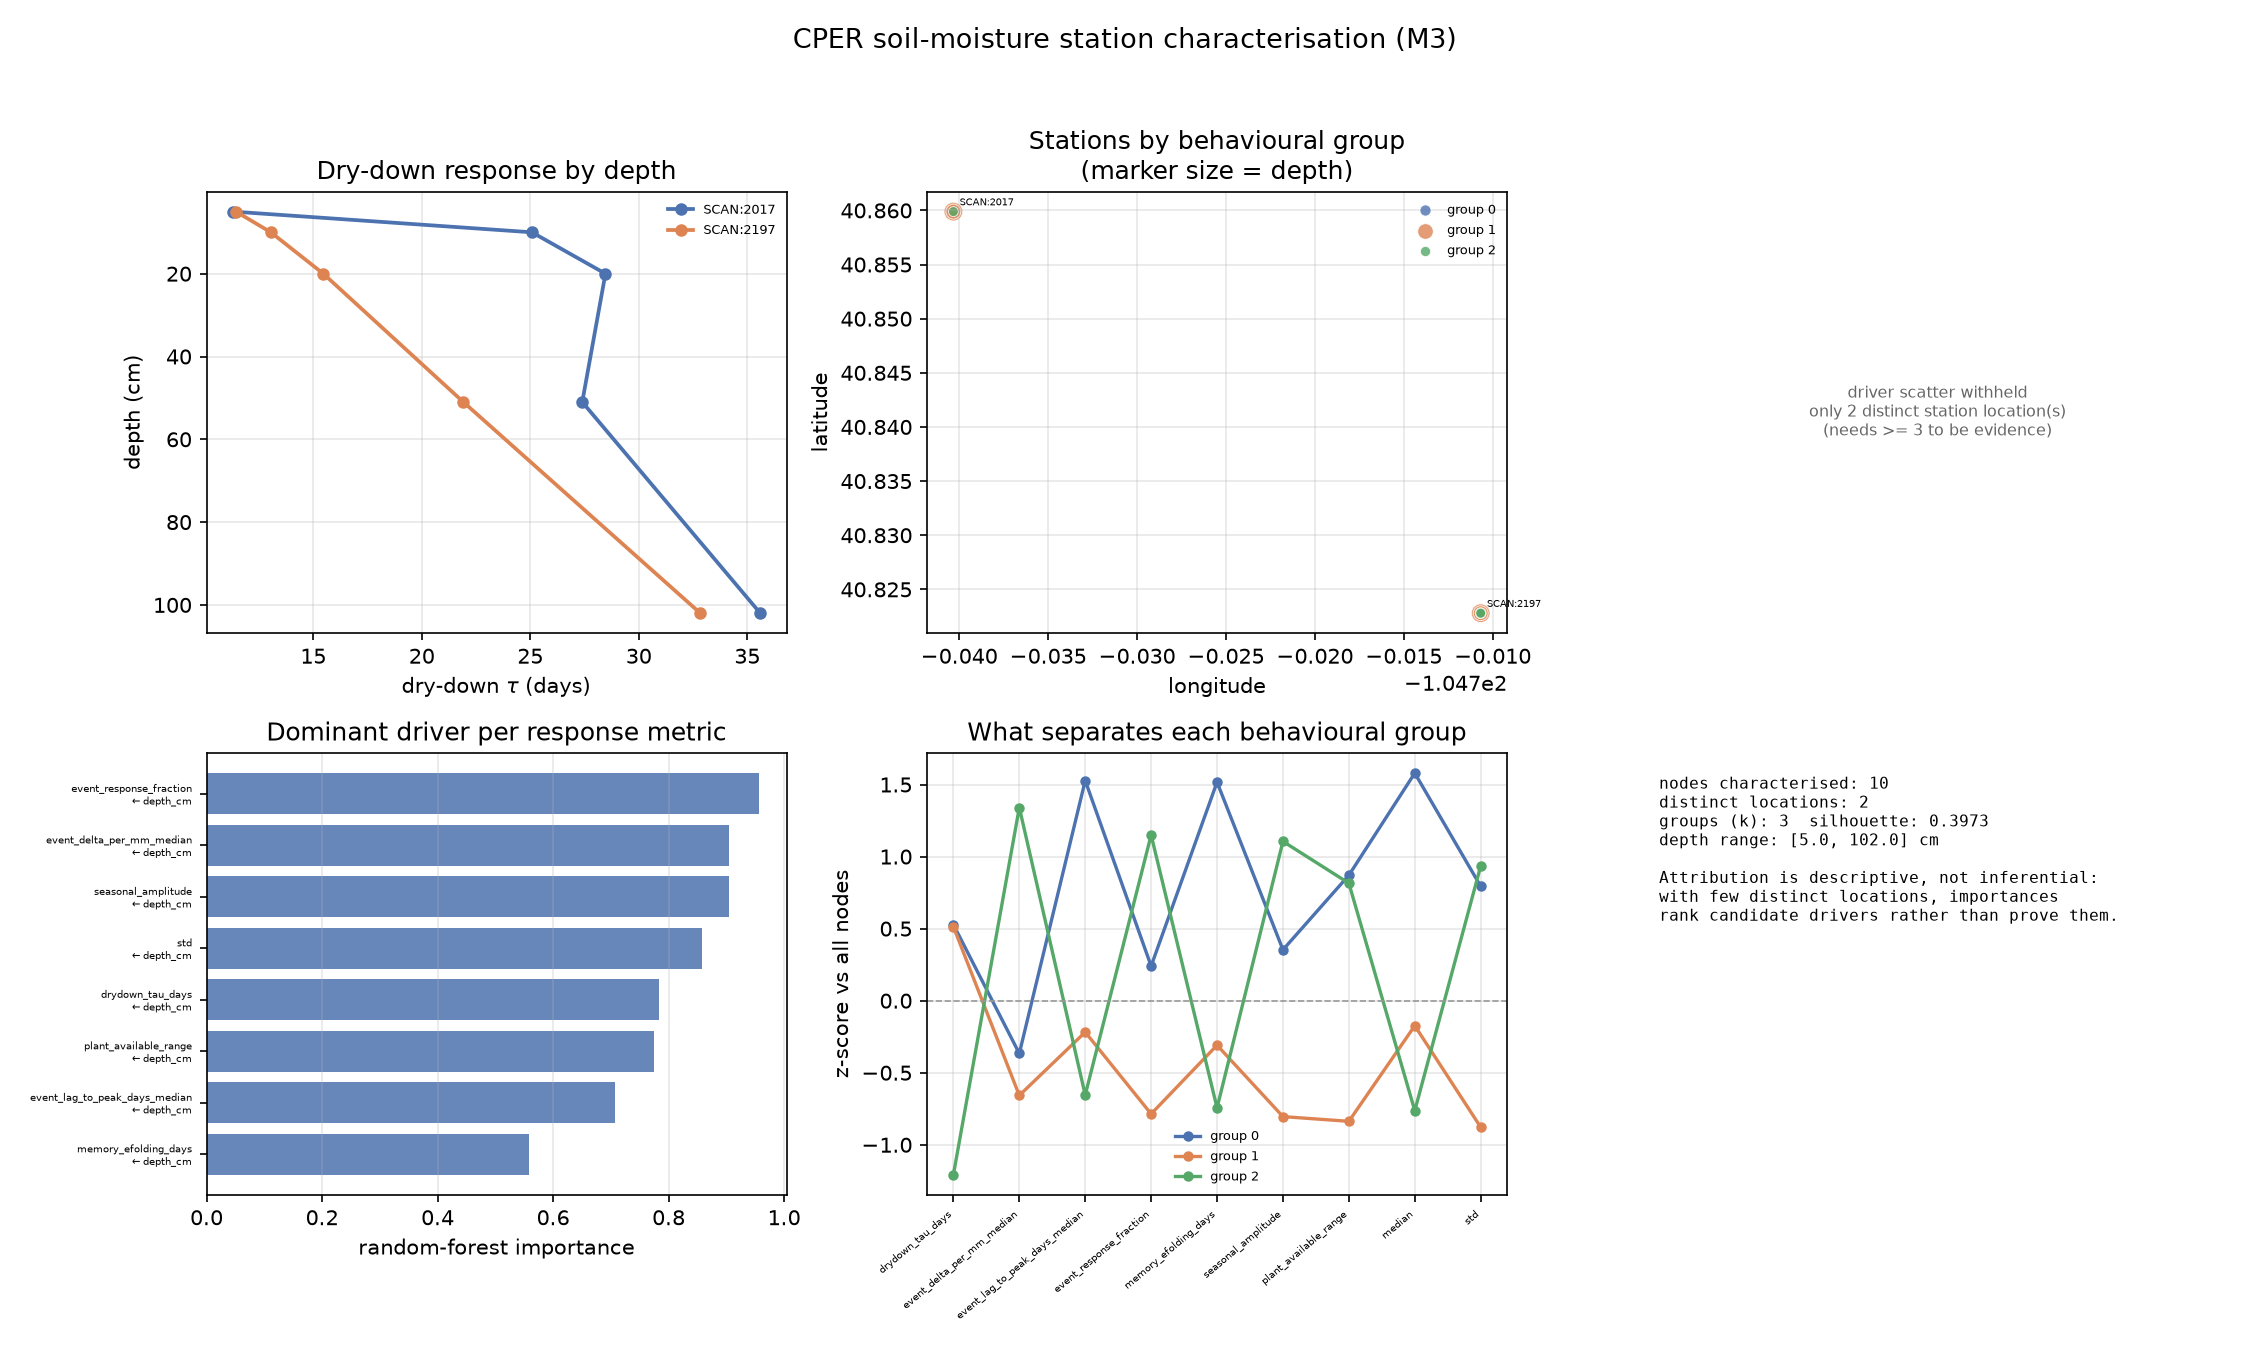

In [15]:
FIG = OUT / "station_characterization.png"
run_stage("visualize_response.py", "--groups", GROUPS, "--similarity", SIM,
          "--covariates", COVS, "--output", FIG,
          "--output-index", OUT / "figure_index.json")

from IPython.display import Image
Image(filename=str(FIG))

---
## 6. Delineate response zones (ask 2, M3)

The second ask: *"delineate areas expected to behave similarly"*. This clusters
the **covariate grid** — all 1.5 M pixels of the M2 stack — rather than the
stations, so it produces zones everywhere on the site, including where no sensor
exists.

Two details matter. **PCA before clustering**: the stack carries the same soil
property at four depth intervals, so the raw bands are heavily collinear and
KMeans on them would silently weight whichever property happens to have the most
bands. And the zones are **validated against the behavioural groups** from
section 5 — labels derived from the covariates, checked against behaviour
derived independently from the observations. That check is allowed to fail, and
below it does.

In [ ]:
ZONES      = OUT / "zones.tif"
ZONES_GJ   = OUT / "soil_moisture_zones.geojson"
ZONE_STATS = OUT / "zone_stats.json"
ZONE_MEM   = OUT / "station_zones.csv"

run_stage("delineate_zones.py", "--covariates", STACK, "--manifest", MANIFEST,
          "--config", CONFIG, "--groups", GROUPS,
          "--output-zones", ZONES, "--output-geojson", ZONES_GJ,
          "--output-stats", ZONE_STATS, "--output-membership", ZONE_MEM,
          must_succeed=True)

zs = json.loads(ZONE_STATS.read_text())
clus = zs["clustering"]
print("\nk = %s   silhouette = %s   (PCA %d components, %.1f%% of variance)" % (
    clus["k"], clus["silhouette"], clus["pca_components"],
    100 * clus["pca_variance_retained"]))
print("station-free zones:", zs["station_free_zones"] or "none")

pd.DataFrame([{
    "zone": int(z),
    "area_ha": d["area_ha"],
    "nodes": d["n_nodes"],
    "station_free": d["station_free"],
    "clay_0_5": (d.get("feature_centroid") or {}).get("clay_0_5"),
    "sand_0_5": (d.get("feature_centroid") or {}).get("sand_0_5"),
    "slope_deg": (d.get("feature_centroid") or {}).get("slope_deg"),
    "twi": (d.get("feature_centroid") or {}).get("twi"),
} for z, d in sorted(zs["zones"].items(), key=lambda kv: int(kv[0]))])

**Do the zones agree with how the site actually behaves?** The adjusted Rand
index compares each node's covariate zone against its behavioural group. A node
gets its zone from its coordinates, so all depth-nodes at one plot share a zone
while their behavioural groups differ by depth — a low ARI over all depths is
therefore expected, and `surface_only` is the comparable number.

In [ ]:
val = zs["validation"]
if val.get("skipped"):
    print("validation skipped:", val["skipped"])
else:
    print("adjusted Rand index (all depths):", val["adjusted_rand_index"])
    if "surface_only" in val:
        print("adjusted Rand index (surface) :",
              val["surface_only"]["adjusted_rand_index"],
              "on", val["surface_only"]["n_nodes"], "nodes")
    print("distinct locations backing it :", val["n_distinct_locations"])
    print("\nbehavioural group x covariate zone:")
    # .T because the JSON nests zone inside group, and pandas would otherwise
    # put the groups on the columns and label them "zone".
    display(pd.DataFrame(val["crosstab"]).T.fillna(0).astype(int)
              .rename_axis("zone", axis=1).rename_axis("group"))

---
## 7. The site-wide dynamic map (ask 3, M4)

The third ask in full: current soil moisture **everywhere**, not just at the
sensors. Two tiers, so it degrades instead of breaking.

**Tier 1** works in relative saturation `S = θ/θ_s` rather than raw water
content. A station reporting `S = 0.4` says "this profile is at 40 % of its own
pore space", which transfers across a soil boundary; `0.14 m³/m³` does not. Each
pixel gets `θ = (S_clim_zone + ΔS_zone) × θ_s(pixel)`, clipped to
`[θ_r, θ_s]`. Because `θ_s` comes from the *pixel*, the map carries real soil
texture inside each zone instead of flat blocks — that is the streaky drainage
pattern you will see in the figure. A zone with no station borrows its anomaly
from the nearest analogue **in covariate space**, never the nearest neighbour in
metres.

**Tier 2** (random forest on covariates + residual interpolation) is gated on
`analysis.min_stations_for_regression` distinct locations, default 8. With the
~7 the public network provides it stays off, and the output records why. A
49-covariate forest fitted to 7 points would be decoration, not a refinement.

In [ ]:
NOW_TIF   = OUT / "soil_moisture_now.tif"
UNC_TIF   = OUT / "soil_moisture_uncertainty.tif"
NOW_JSON  = OUT / "soil_moisture_now.json"
SKILL     = OUT / "estimation_skill.json"

run_stage("estimate_soil_moisture.py", "--points", SM, "--zones", ZONES,
          "--zone-stats", ZONE_STATS, "--covariates", STACK,
          "--manifest", MANIFEST, "--fingerprints", *fingerprints,
          "--config", CONFIG, "--as-of", END,
          "--output-map", NOW_TIF, "--output-uncertainty", UNC_TIF,
          "--output-json", NOW_JSON, "--output-skill", SKILL,
          must_succeed=True)

now = json.loads(NOW_JSON.read_text())
s = now["summary"]
print("\ntier used        :", now["provenance"]["tier_used"])
print("reporting stations:", now["n_reporting_stations"],
      "at", now["n_distinct_locations"], "distinct locations")
print("site mean        :", s["mean"], now["units"])
print("mean 1-sigma     :", s["mean_uncertainty"])
print("station-free area:", s["area_ha_station_free"], "ha")
if now["method"].get("tier2_note"):
    print("\n" + now["method"]["tier2_note"])

pd.DataFrame(now["zones"])[
    ["zone", "area_ha", "n_stations", "station_free", "analogue_donor_zone",
     "mean_estimate", "mean_uncertainty"]]

**The skill numbers are the point of this cell.** Leave-one-station-out drops
each station in turn, re-estimates without it, and reads the map at that
station's own pixel. It is reported against two baselines that cost nothing,
because an RMSE with nothing to compare it to is not a skill number.

In [ ]:
sk = json.loads(SKILL.read_text())
if sk.get("skipped"):
    print("skill skipped:", sk["skipped"])
else:
    display(pd.DataFrame([
        dict(estimator="zone-anchored (tier 1)", **sk["overall"]),
        dict(estimator="baseline: site mean", **sk["baseline_site_mean"]),
        dict(estimator="baseline: climatology", **sk["baseline_climatology"]),
    ]).set_index("estimator"))
    print("verdict:", sk["verdict"])
    print("\n" + sk["caveat"])
    display(pd.DataFrame(sk["per_station"])[
        ["station", "zone", "observed", "predicted", "error", "source"]])

### The map

Six panels: the current estimate, its uncertainty, the zones with station-free
areas hatched, per-zone recent time series, station current-vs-climatology, and
the skill summary. The estimate panel uses a continuous colour scale with the
dryness class breaks marked as ticks — a hard class-binned image would be one
flat colour whenever the whole site sits in a single class, which is exactly
what a dry July looks like here.

In [ ]:
MAP_PNG  = OUT / "soil_moisture_map.png"
MAP_HTML = OUT / "soil_moisture_map.html"

run_stage("visualize_soil_moisture.py", "--map", NOW_TIF,
          "--uncertainty", UNC_TIF, "--zones", ZONES,
          "--geojson", ZONES_GJ, "--zone-stats", ZONE_STATS,
          "--now-json", NOW_JSON, "--skill", SKILL, "--points", SM,
          "--fingerprints", *fingerprints,
          "--output-figure", MAP_PNG, "--output-html", MAP_HTML)

Image(filename=str(MAP_PNG))

There is also a **self-contained HTML page** next to that figure — zone polygons
as inline SVG, station markers with click-through fingerprint popups, panels
embedded as base64, and no network access of any kind. It opens straight from
disk or drops on any web host, which is the least-friction way to hand a field
researcher something that looks like it updates.

In [ ]:
print(MAP_HTML, "->", "%.1f KB" % (MAP_HTML.stat().st_size / 1024)
      if MAP_HTML.exists() else "not written")

# Prove it is really self-contained before sending it anywhere.
if MAP_HTML.exists():
    import re
    html = MAP_HTML.read_text()
    ext = [u for u in re.findall(r'https?://[^"\'\s)]+', html)
           if "w3.org" not in u and "ogc" not in u]
    print("external URLs:", len(ext), "(0 means it will render offline)")

from IPython.display import IFrame
IFrame(src=str(MAP_HTML.relative_to(WF)), width="100%", height=600)

---
## What to look at, and what not to claim

**Solid.** Fingerprints are computed from multi-year records and the depth
relationships are physically checkable: τ rises with depth (deep soil dries
slowly) and event response attenuates with depth (the wetting front weakens
going down). If a sensor violates both, suspect the sensor before the soil.
The SSURGO component at each station is an independent read on its soil, and
`harmonization_report.json` states exactly which source contributed what.

**Provisional.** Attribution across stations rests on very few *distinct
locations* — about four public stations, not the ~30 the original feedback
implied. Importances rank candidate drivers; they do not establish them. The
code refuses to fit below 6 nodes or 3 distinct locations, and the figure
withholds the driver-scatter panel on the same test. Those guards are
deliberate: a covariate taking two values across the network will correlate
with anything.

**Not here yet.** Recurrence — running the nowcast on a cadence so the map
maintains itself — is the last unbuilt piece. The IDW preview grid inside
`soil_moisture_points.json` is still only a point-scale preview; the defensible
spatial product is `soil_moisture_now.tif` from the zone-anchored upscaling.

**The M4 result to read honestly.** Leave-one-station-out gives the
zone-anchored estimate an RMSE of ~0.015 m³/m³ against a **site-mean baseline of
the same ~0.014** and a climatology-only baseline of ~0.039. So the *anomaly*
step is doing real work — 2.6× better than climatology — while the *zoning*
currently buys nothing measurable. Independently, the adjusted Rand index
between the covariate zones and the behavioural groups is slightly **negative**.
Both point at the same cause: 6 of 7 reporting stations fall in one zone, so the
zone labels have almost no discriminating power where they can be checked. This
is reported rather than tuned away; `estimation_skill.json` carries a
plain-language `verdict` and the HTML page prints it above the map.

**Open question that would change everything:** where the researcher's own
~30-station network lives and in what format. A station metadata table plus a
few sample logger exports unblocks the whole map (`SPEC.md` §11 Q1).

### Next

To run this same pipeline as a Pegasus DAG — parallel fan-out over ~120
monthly NEON fetches, automatic retry on flaky station APIs, data reuse that
takes the planned workflow from 177 jobs to 16, and provenance from raw
observation to published map — open
**`Access-CPER-SoilMoisture-Workflow.ipynb`**.